In [1]:
# Cell 0: Mount Drive & Install Dependencies
from google.colab import drive
drive.mount('/content/drive')

!pip install torch torchvision torchaudio
!pip install matplotlib numpy pillow scikit-image opencv-python pandas seaborn imageio
!pip install -q imageio-ffmpeg

Mounted at /content/drive


In [2]:
# Cell 1: Imports and device configuration
import sys
sys.path.append('/content/drive/MyDrive/ResearchProject')

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import time

from unet_denoiser_v1 import BlindVideoDenoiserUNet
from video_io import VideoLoader, VideoSaver, VideoProcessor

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

project_dir = Path('/content/drive/MyDrive/ResearchProject')
benchmark_dir = project_dir / 'benchmark_results_v2'
benchmark_dir.mkdir(exist_ok=True)

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
GPU Memory: 42.4 GB


In [3]:
# Cell 2: Import the framework modules
# (If using files on Drive, just import them. If pasting inline, use the
#  inverse_problem_framework.py contents from the file I gave you.)

from inverse_problem_framework import LinearOperator, VideoDenoiser, KadkhodaieSolver
from linear_operators import DemosaicingOperator, create_bayer_mosaic
from denoiser_wrappers import BlindVideoDenoiserWrapper
from inverse_framework_benchmark import DemosaicingBenchmark

print("✓ Framework imported")

✓ Framework imported


In [4]:
# Cell 3: No separate operator definition needed.
# The DemosaicingOperator is created per-video (since it depends on H, W).
# We'll create it in the test cells below.
print("✓ DemosaicingOperator will be created per-video (depends on H, W)")

✓ DemosaicingOperator will be created per-video (depends on H, W)


In [5]:
# Cell 4: Denoiser wrapper (corrected)

class BlindVideoDenoiserWrapper(VideoDenoiser):
    """
    Wrapper for BlindVideoDenoiserUNet.
    Handles temporal sliding window and spatial padding.
    """

    def __init__(self, model, device='cuda', pad_to=8):
        self.model = model.to(device)
        self.device = device
        self.pad_to = pad_to
        self.model.eval()

    def _pad(self, frame):
        C, H, W = frame.shape
        ph = (self.pad_to - H % self.pad_to) % self.pad_to
        pw = (self.pad_to - W % self.pad_to) % self.pad_to
        if ph > 0 or pw > 0:
            frame = F.pad(frame, (0, pw, 0, ph), mode='reflect')
        return frame, (H, W)

    def _unpad(self, frame, orig):
        return frame[:, :orig[0], :orig[1]]

    def denoise(self, noisy_video: torch.Tensor, noise_std: float = 0.0) -> torch.Tensor:
        T, C, H, W = noisy_video.shape
        noisy_video = noisy_video.to(self.device)
        frames = []
        with torch.no_grad():
            for t in range(T):
                p, c, n = max(0, t-1), t, min(T-1, t+1)
                d = self.denoise_frame(noisy_video[p], noisy_video[c], noisy_video[n], noise_std)
                frames.append(d)
        return torch.clamp(torch.stack(frames), 0, 1)

    def denoise_frame(self, prev_frame, curr_frame, next_frame, noise_std=0.0):
        pf, _ = self._pad(prev_frame)
        cf, orig = self._pad(curr_frame)
        nf, _ = self._pad(next_frame)
        triplet = torch.cat([pf, cf, nf], dim=0).unsqueeze(0).to(self.device)
        with torch.no_grad():
            out = self.model(triplet)
        return torch.clamp(self._unpad(out.squeeze(0), orig), 0, 1)

print("✓ Denoiser wrapper defined")

✓ Denoiser wrapper defined


In [6]:
# Cell 5: Load your trained denoiser
print("Loading trained blind video denoiser...")

checkpoint_path = project_dir / 'checkpoints' / 'best_model.pt'

model = BlindVideoDenoiserUNet(in_channels=9, out_channels=3, base_channels=64, num_stages=3)
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"✓ Loaded from epoch {checkpoint['epoch']}")
print(f"  Train loss: {checkpoint['train_loss']:.6f}")
print(f"  Val loss:   {checkpoint['val_loss']:.6f}")

# Wrap for framework — pad_to=8 for 3-stage UNet (2^3=8)
your_denoiser = BlindVideoDenoiserWrapper(model, device=device, pad_to=8)
print("✓ Denoiser wrapped and ready")

Loading trained blind video denoiser...
✓ Loaded from epoch 94
  Train loss: 18.681205
  Val loss:   17.788655
✓ Denoiser wrapped and ready


In [17]:
# Cell 7: Load test videos for benchmark
print("Loading test videos...")
davis_root = Path('/content/drive/MyDrive/ResearchProject/DAVISDataset')
test_videos = {}
video_dirs = sorted([d for d in davis_root.iterdir() if d.is_dir()])[:5]

for vdir in video_dirs:
    name = vdir.name
    print(f"  Loading {name}...", end=' ', flush=True)
    try:
        v = VideoLoader.load_frame_sequence(
            str(vdir), max_frames=20, resize=(480, 856), device=device
        )
        test_videos[name] = v
        print("✓")
    except Exception as e:
        print(f"✗ ({e})")

print(f"\nLoaded {len(test_videos)} test videos")

Loading test videos...
  Loading baseball... Loaded 20 frames from: /content/drive/MyDrive/ResearchProject/DAVISDataset/baseball
  Shape: torch.Size([20, 3, 480, 856]) (T, C, H, W)
✓
  Loading basketball-game... Loaded 20 frames from: /content/drive/MyDrive/ResearchProject/DAVISDataset/basketball-game
  Shape: torch.Size([20, 3, 480, 856]) (T, C, H, W)
✓
  Loading bear... Loaded 20 frames from: /content/drive/MyDrive/ResearchProject/DAVISDataset/bear
  Shape: torch.Size([20, 3, 480, 856]) (T, C, H, W)
✓
  Loading bears-ball... Loaded 20 frames from: /content/drive/MyDrive/ResearchProject/DAVISDataset/bears-ball
  Shape: torch.Size([20, 3, 480, 856]) (T, C, H, W)
✓
  Loading bike-packing... Loaded 20 frames from: /content/drive/MyDrive/ResearchProject/DAVISDataset/bike-packing
  Shape: torch.Size([20, 3, 480, 856]) (T, C, H, W)
✓

Loaded 5 test videos


In [18]:
# Cell 7: DEMOSAICING — Run solver on ALL test videos
print("=" * 60)
print("DEMOSAICING TEST (RGGB Bayer Pattern)")
print("=" * 60)

from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim

# Store everything for visualization later
all_demosaic_results = {}

for video_name, clean in test_videos.items():
    T, C, H, W = clean.shape
    print(f"\n--- {video_name} ({T} frames, {W}×{H}) ---")

    operator, mosaiced, naive_demosaiced = create_bayer_mosaic(
        clean, H, W, pattern='RGGB', device=device
    )

    solver = KadkhodaieSolver(operator, your_denoiser, device=device)

    restored, metrics = solver.solve(
        mosaiced,
        sigma_0=0.1,
        sigma_L=0.002,
        h0=0.01,
        beta=0.1,
        max_iterations=2000,
        verbose=True,
        log_freq=200,
    )

    all_demosaic_results[video_name] = {
        'clean': clean,
        'mosaiced': mosaiced,
        'naive': naive_demosaiced,
        'restored': restored,
        'metrics': metrics,
    }

    # Quick per-video summary
    mid = T // 2
    c = clean[mid].permute(1, 2, 0).cpu().numpy()
    n = naive_demosaiced[mid].permute(1, 2, 0).cpu().numpy()
    r = restored[mid].permute(1, 2, 0).cpu().numpy()
    print(f"  Naive:  {compute_psnr(c, np.clip(n,0,1), data_range=1.0):.2f} dB")
    print(f"  Solver: {compute_psnr(c, np.clip(r,0,1), data_range=1.0):.2f} dB")

print(f"\n{'=' * 60}")
print(f"Done — {len(all_demosaic_results)} videos processed")
print(f"{'=' * 60}")

DEMOSAICING TEST (RGGB Bayer Pattern)

--- baseball (20 frames, 856×480) ---
  Converged in 90 iters (13.2s), final sigma=0.001946
  Naive:  28.31 dB
  Solver: 33.96 dB

--- basketball-game (20 frames, 856×480) ---
  Converged in 95 iters (13.9s), final sigma=0.001840
  Naive:  28.07 dB
  Solver: 39.43 dB

--- bear (20 frames, 856×480) ---
  Converged in 89 iters (13.0s), final sigma=0.001825
  Naive:  27.45 dB
  Solver: 37.14 dB

--- bears-ball (20 frames, 856×480) ---
  Converged in 88 iters (12.9s), final sigma=0.001936
  Naive:  38.09 dB
  Solver: 44.60 dB

--- bike-packing (20 frames, 856×480) ---
  Converged in 95 iters (13.9s), final sigma=0.001976
  Naive:  27.30 dB
  Solver: 35.00 dB

Done — 5 videos processed


In [19]:
# Cell 8: Visualize results — one frame at a time, each video
frames_per_video = 6

for video_name, data in all_demosaic_results.items():
    clean = data['clean']
    naive = data['naive']
    restored = data['restored']
    T = clean.shape[0]

    step = max(1, T // frames_per_video)
    frame_indices = list(range(0, T, step))[:frames_per_video]

    print(f"\n--- {video_name} ({T} frames) ---")

    for idx in frame_indices:
        c_np = clean[idx].permute(1, 2, 0).cpu().numpy()
        n_np = naive[idx].permute(1, 2, 0).cpu().numpy()
        r_np = restored[idx].permute(1, 2, 0).cpu().numpy()

        p_n = compute_psnr(c_np, np.clip(n_np, 0, 1), data_range=1.0)
        p_r = compute_psnr(c_np, np.clip(r_np, 0, 1), data_range=1.0)

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        axes[0].imshow(np.clip(c_np, 0, 1))
        axes[0].set_title('Clean', fontsize=12, fontweight='bold')
        axes[0].axis('off')

        axes[1].imshow(np.clip(n_np, 0, 1))
        axes[1].set_title(f'Naive Interp — PSNR={p_n:.1f} dB', fontsize=12, fontweight='bold')
        axes[1].axis('off')

        axes[2].imshow(np.clip(r_np, 0, 1))
        axes[2].set_title(f'Solver — PSNR={p_r:.1f} dB', fontsize=12, fontweight='bold')
        axes[2].axis('off')

        plt.suptitle(f'{video_name} — Frame {idx+1}/{T}',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

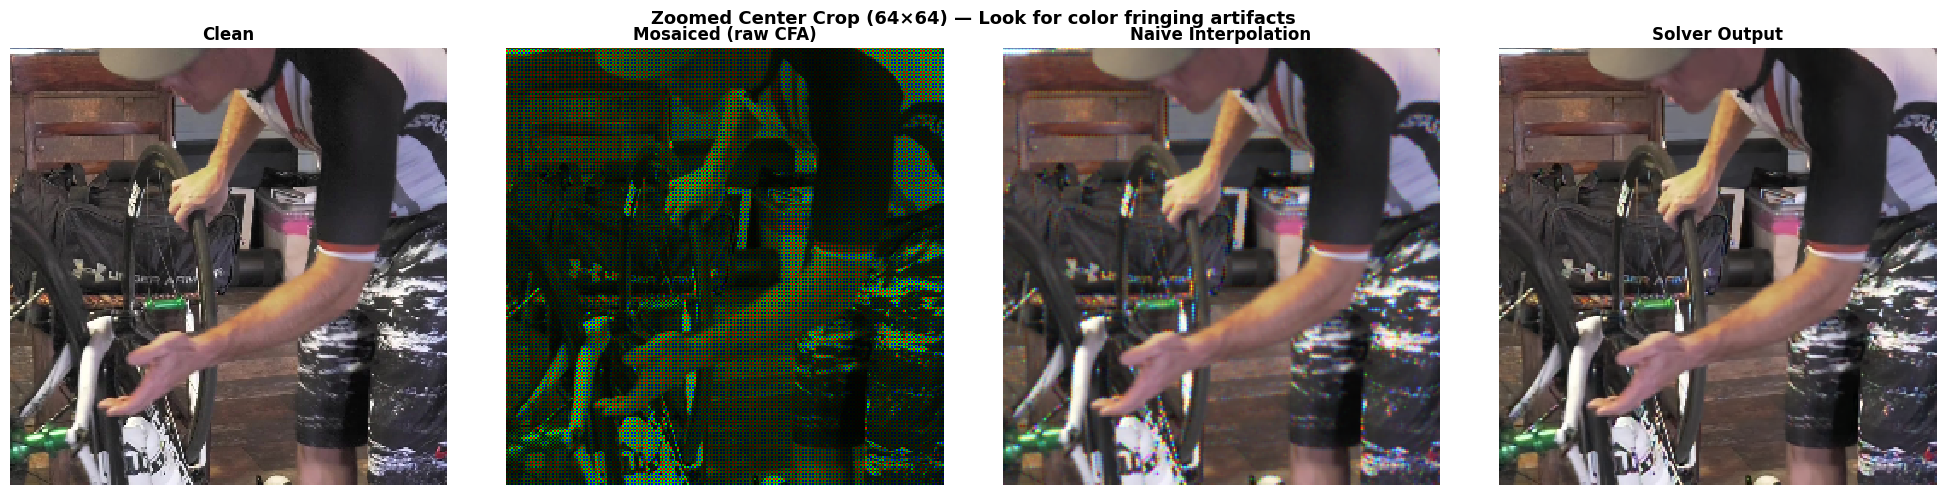

In [20]:
# Cell 10: Zoomed-in comparison (demosaicing artifacts are best seen zoomed)
mid = T // 2

# Pick a 64x64 crop from center
cy, cx = H // 2, W // 2
cs = 256  # crop size
y1, y2 = cy - cs // 2, cy + cs // 2
x1, x2 = cx - cs // 2, cx + cs // 2

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

crops = [
    (clean[mid, :, y1:y2, x1:x2], 'Clean'),
    (mosaiced[mid, :, y1:y2, x1:x2], 'Mosaiced (raw CFA)'),
    (naive_demosaiced[mid, :, y1:y2, x1:x2], 'Naive Interpolation'),
    (restored[mid, :, y1:y2, x1:x2], 'Solver Output'),
]

for ax, (crop, title) in zip(axes, crops):
    crop_np = crop.permute(1, 2, 0).cpu().numpy()
    ax.imshow(np.clip(crop_np, 0, 1), interpolation='nearest')
    ax.set_title(title, fontweight='bold')
    ax.axis('off')

plt.suptitle('Zoomed Center Crop (64×64) — Look for color fringing artifacts',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(benchmark_dir / 'demosaicing_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Cell 11: Full benchmark across all test videos
print("=" * 60)
print("FULL DEMOSAICING BENCHMARK")
print("=" * 60)

all_results = []

for video_name, clean_vid in test_videos.items():
    T, C, H, W = clean_vid.shape
    print(f"\n  Video: {video_name} ({T} frames, {H}×{W})")

    op, mos, naive = create_bayer_mosaic(clean_vid, H, W, pattern='RGGB', device=device)

    solver = KadkhodaieSolver(op, your_denoiser, device=device)
    restored_vid, met = solver.solve(
        mos, sigma_0=0.1, sigma_L=0.002, h0=0.01, beta=0.1,
        max_iterations=2000, verbose=False
    )

    for t in range(T):
        c = clean_vid[t].permute(1, 2, 0).cpu().numpy()
        n = naive[t].permute(1, 2, 0).cpu().numpy()
        r = restored_vid[t].permute(1, 2, 0).cpu().numpy()

        all_results.append({
            'Video': video_name,
            'Frame': t,
            'PSNR Naive': compute_psnr(c, np.clip(n, 0, 1), data_range=1.0),
            'PSNR Solver': compute_psnr(c, np.clip(r, 0, 1), data_range=1.0),
            'SSIM Naive': compute_ssim(c, np.clip(n, 0, 1), data_range=1.0, channel_axis=2),
            'SSIM Solver': compute_ssim(c, np.clip(r, 0, 1), data_range=1.0, channel_axis=2),
        })

    # Print per-video average
    vid_rows = [r for r in all_results if r['Video'] == video_name]
    avg_naive = np.mean([r['PSNR Naive'] for r in vid_rows])
    avg_solver = np.mean([r['PSNR Solver'] for r in vid_rows])
    print(f"    Naive: {avg_naive:.2f} dB → Solver: {avg_solver:.2f} dB "
          f"(Δ = {avg_solver - avg_naive:+.2f} dB)")

results_df = pd.DataFrame(all_results)
results_df['PSNR Improvement'] = results_df['PSNR Solver'] - results_df['PSNR Naive']
results_df['SSIM Improvement'] = results_df['SSIM Solver'] - results_df['SSIM Naive']

print(f"\n{'=' * 60}")
print("OVERALL SUMMARY")
print(f"{'=' * 60}")
print(f"Mean PSNR — Naive: {results_df['PSNR Naive'].mean():.2f} dB | "
      f"Solver: {results_df['PSNR Solver'].mean():.2f} dB | "
      f"Δ: {results_df['PSNR Improvement'].mean():+.2f} dB")
print(f"Mean SSIM — Naive: {results_df['SSIM Naive'].mean():.4f} | "
      f"Solver: {results_df['SSIM Solver'].mean():.4f} | "
      f"Δ: {results_df['SSIM Improvement'].mean():+.4f}")

results_df.to_csv(benchmark_dir / 'demosaicing_benchmark.csv', index=False)
print(f"\nResults saved to {benchmark_dir / 'demosaicing_benchmark.csv'}")

FULL DEMOSAICING BENCHMARK

  Video: baseball (20 frames, 480×856)
    Naive: 28.08 dB → Solver: 33.60 dB (Δ = +5.53 dB)

  Video: basketball-game (20 frames, 480×856)
    Naive: 28.17 dB → Solver: 39.09 dB (Δ = +10.93 dB)

  Video: bear (20 frames, 480×856)
    Naive: 27.41 dB → Solver: 37.04 dB (Δ = +9.63 dB)

  Video: bears-ball (20 frames, 480×856)
    Naive: 36.58 dB → Solver: 44.11 dB (Δ = +7.53 dB)

  Video: bike-packing (20 frames, 480×856)
    Naive: 27.24 dB → Solver: 34.85 dB (Δ = +7.61 dB)

OVERALL SUMMARY
Mean PSNR — Naive: 29.49 dB | Solver: 37.74 dB | Δ: +8.25 dB
Mean SSIM — Naive: 0.8859 | Solver: 0.9770 | Δ: +0.0911

Results saved to /content/drive/MyDrive/ResearchProject/benchmark_results_v2/demosaicing_benchmark.csv


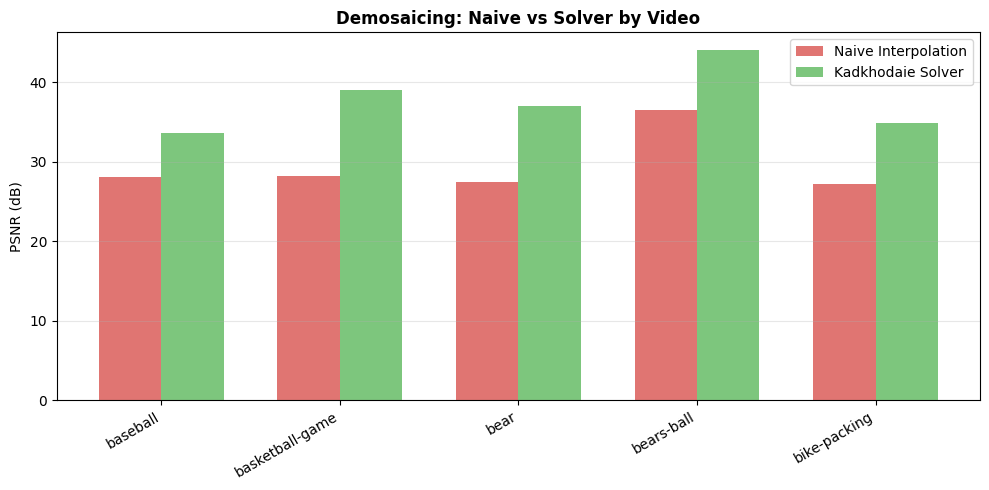

In [22]:
# Cell 12: Summary bar chart
summary = results_df.groupby('Video').agg(
    PSNR_Naive=('PSNR Naive', 'mean'),
    PSNR_Solver=('PSNR Solver', 'mean'),
).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(summary))
w = 0.35

ax.bar(x - w/2, summary['PSNR_Naive'], w, label='Naive Interpolation', color='#d9534f', alpha=0.8)
ax.bar(x + w/2, summary['PSNR_Solver'], w, label='Kadkhodaie Solver', color='#5cb85c', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=30, ha='right')
ax.set_ylabel('PSNR (dB)')
ax.set_title('Demosaicing: Naive vs Solver by Video', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(benchmark_dir / 'demosaicing_summary.png', dpi=150, bbox_inches='tight')
plt.show()